# Exploratory Data Analysis

This notebook explores the Fraud Detection Handbook transaction dataset before feature engineering and model development.

The objective is to understand the dataset structure, data quality, class imbalance, transaction behavior, and potential predictive signals while identifying possible sources of data leakage.

## 1. Dataset Overview

The dataset contains simulated payment transactions generated by the Fraud Detection Handbook framework. We first inspect its size, schema, date range, and the number of unique customers and terminals.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT / "data" / "raw" / "transactions.parquet"

df = pd.read_parquet(DATA_FILE)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 1,754,155
Columns: 9


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        int64         
 3   TERMINAL_ID        int64         
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    int64         
 6   TX_TIME_DAYS       int64         
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(7)
memory usage: 120.4 MB


## 2. Data Quality

Before building the modeling pipeline, the dataset is checked for missing values and duplicate observations. Transaction identifiers are also verified for uniqueness.

In [3]:
print(f"Date range: {df['TX_DATETIME'].min()} → {df['TX_DATETIME'].max()}")
print(f"Customers: {df['CUSTOMER_ID'].nunique():,}")
print(f"Terminals: {df['TERMINAL_ID'].nunique():,}")

print("\nMissing values:")
print(df.isna().sum())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(
    "Duplicate transaction IDs:",
    f"{df['TRANSACTION_ID'].duplicated().sum():,}",
)

Date range: 2018-04-01 00:00:31 → 2018-09-30 23:59:57
Customers: 4,990
Terminals: 10,000

Missing values:
TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

Duplicate rows: 0
Duplicate transaction IDs: 0


**Observation:** The dataset contains no missing values, duplicate rows, or duplicate transaction identifiers. Therefore, extensive missing-value handling or deduplication is not required during preprocessing.

## 3. Class Distribution

Fraud detection is typically a highly imbalanced classification problem. Understanding the target distribution is important because accuracy alone can be misleading when the positive class is rare.

In [4]:
fraud_summary = (
    df["TX_FRAUD"]
    .value_counts()
    .sort_index()
    .rename_axis("TX_FRAUD")
    .to_frame("count")
)

fraud_summary["percentage"] = (
    fraud_summary["count"] / len(df) * 100
)

fraud_summary

,count,percentage
TX_FRAUD,,
0,1739474,99.163073
1,14681,0.836927


**Observation:** Fraudulent transactions represent approximately **0.84%** of all transactions. A classifier predicting every transaction as legitimate would therefore achieve more than 99% accuracy while detecting no fraud.

For this reason, model evaluation will focus primarily on metrics such as precision, recall, F1-score, and PR-AUC rather than accuracy alone.

## 4. Fraud Scenarios

The simulated dataset contains several fraud scenarios. Their distribution is inspected to better understand how fraudulent transactions are represented in the data.

In [5]:
scenario_summary = (
    df["TX_FRAUD_SCENARIO"]
    .value_counts()
    .sort_index()
    .rename_axis("scenario")
    .to_frame("count")
)

scenario_summary["percentage"] = (
    scenario_summary["count"] / len(df) * 100
)

scenario_summary

,count,percentage
scenario,,
0,1739474,99.163073
1,973,0.055468
2,9077,0.517457
3,4631,0.264002


**Data leakage consideration:** `TX_FRAUD_SCENARIO` directly describes the scenario used to generate fraudulent transactions. Since non-zero scenario values correspond to fraudulent observations, this variable contains information derived from the target-generation process.

It will therefore be used only for exploratory analysis and excluded from all model features.

## 5. Transaction Amount Analysis

Transaction amounts are compared between legitimate and fraudulent transactions to determine whether transaction magnitude provides an initial predictive signal.

In [6]:
df.groupby("TX_FRAUD")["TX_AMOUNT"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
TX_FRAUD,,,,,,
0,1739474,52.977907,44.49,39.421733,0.00,219.98
1,14681,131.168024,72.22,154.485795,0.02,2628.00


**Observation:** Fraudulent transactions have substantially higher average and median transaction amounts than legitimate transactions. The fraud class also exhibits considerably greater variance and contains much larger transaction values.

Transaction amount therefore appears to contain useful predictive information, although behavioral features based on customer and terminal history will be required to capture more complex fraud patterns.

## 6. Temporal Analysis

Transaction behavior may vary depending on the time of day or day of the week. This section examines whether fraudulent transactions exhibit temporal patterns that could provide useful predictive information.

These patterns will also help determine which time-based features should be included in the feature engineering pipeline.

In [7]:
eda_df = df.copy()

eda_df["TX_HOUR"] = eda_df["TX_DATETIME"].dt.hour
eda_df["TX_DAY_OF_WEEK"] = eda_df["TX_DATETIME"].dt.dayofweek

In [8]:
hourly_summary = eda_df.groupby("TX_HOUR").agg(
    transactions=("TX_FRAUD", "size"),
    frauds=("TX_FRAUD", "sum"),
    fraud_rate=("TX_FRAUD", "mean"),
)

hourly_summary["fraud_rate_pct"] = (
    hourly_summary["fraud_rate"] * 100
)

hourly_summary

,transactions,frauds,fraud_rate,fraud_rate_pct
TX_HOUR,,,,
0,15137,142,0.009381,0.938099
1,21861,214,0.009789,0.978912
2,30140,246,0.008162,0.816191
3,40380,311,0.007702,0.770183
4,52403,461,0.008797,0.879721
5,65168,533,0.008179,0.817886
6,79880,675,0.008450,0.845018
7,94030,807,0.008582,0.858237
8,106617,905,0.008488,0.848833


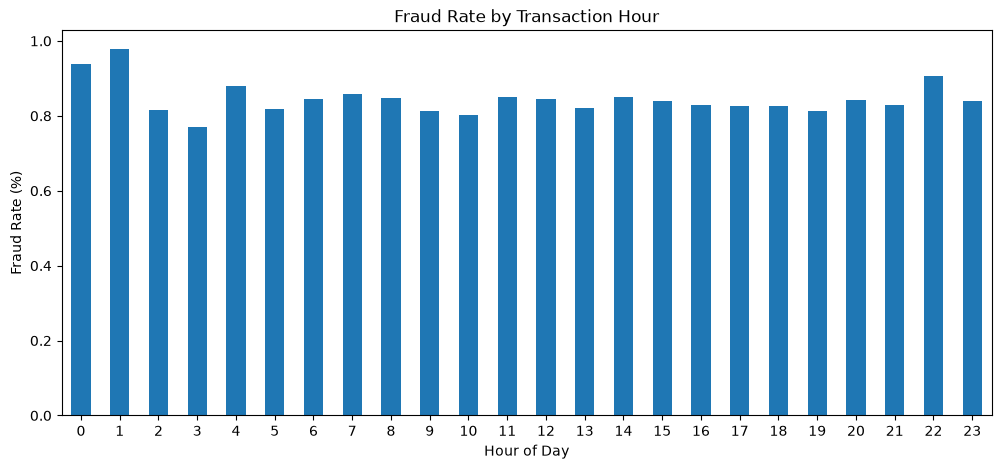

In [9]:
hourly_summary["fraud_rate_pct"].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [10]:
daily_summary = eda_df.groupby("TX_DAY_OF_WEEK").agg(
    transactions=("TX_FRAUD", "size"),
    frauds=("TX_FRAUD", "sum"),
    fraud_rate=("TX_FRAUD", "mean"),
)

daily_summary["fraud_rate_pct"] = (
    daily_summary["fraud_rate"] * 100
)

daily_summary

,transactions,frauds,fraud_rate,fraud_rate_pct
TX_DAY_OF_WEEK,,,,
0,249707,2121,0.008494,0.849395
1,248971,2066,0.008298,0.829816
2,248716,2112,0.008492,0.849161
3,249579,2166,0.008679,0.867861
4,248797,2069,0.008316,0.831602
5,248884,2101,0.008442,0.844168
6,259501,2046,0.007884,0.788436


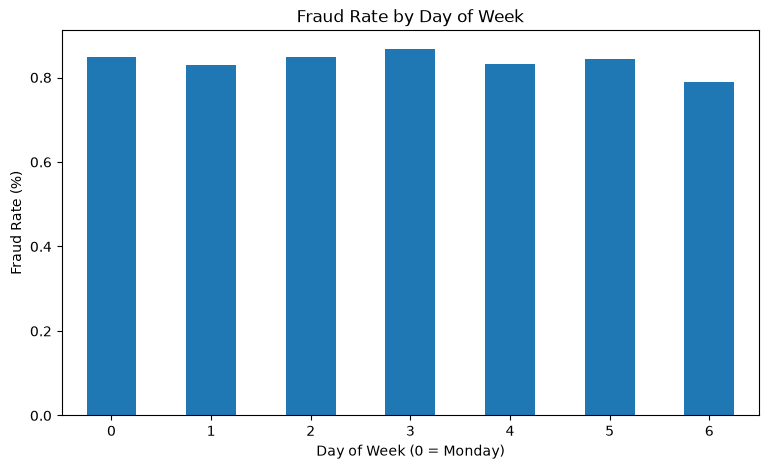

In [11]:
daily_summary["fraud_rate_pct"].plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

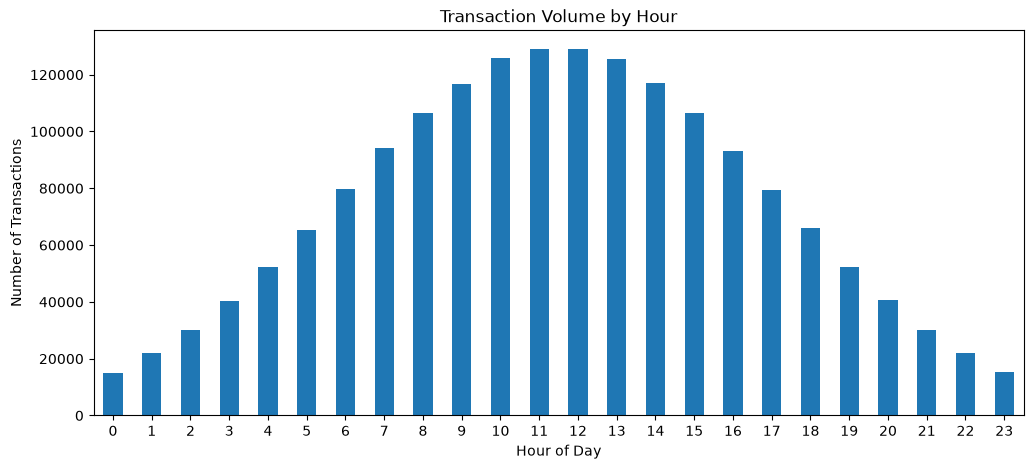

In [12]:
hourly_summary["transactions"].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

**Observation:** Fraud rates remain relatively stable across both transaction hours and days of the week. Some variation is visible during low-volume nighttime hours, but no strong temporal fraud pattern emerges from the raw time variables.

Transaction volume follows a clear daily cycle, peaking around midday and decreasing substantially during nighttime hours.

Based on these results, transaction hour and day of week may still be retained as low-cost contextual features, but they are unlikely to provide strong predictive power on their own. More informative signals are expected to come from customer and terminal behavioral history.

## 7. Customer Behavioral Analysis

Absolute transaction amount alone does not capture whether a purchase is unusual for a particular customer. A transaction that is normal for one customer may be highly anomalous for another.

This section explores customer-specific transaction behavior to determine whether historical spending patterns can provide stronger fraud signals.

In [13]:
customer_activity = (
    df.groupby("CUSTOMER_ID")
    .agg(
        transaction_count=("TRANSACTION_ID", "count"),
        avg_amount=("TX_AMOUNT", "mean"),
        median_amount=("TX_AMOUNT", "median"),
        fraud_count=("TX_FRAUD", "sum"),
    )
)

customer_activity.describe()

,transaction_count,avg_amount,median_amount,fraud_count
count,4990.000000,4990.000000,4990.000000,4990.000000
mean,351.534068,53.750436,52.574065,2.942084
std,205.106511,29.060778,28.408153,4.385838
min,1.000000,4.943002,4.220000,0.000000
25%,174.000000,28.597279,28.092500,0.000000
50%,347.000000,53.618617,52.452500,2.000000
75%,531.000000,78.665555,76.890000,4.000000
max,767.000000,136.922000,136.620000,45.000000


In [14]:
customer_activity["fraud_rate"] = (
    customer_activity["fraud_count"]
    / customer_activity["transaction_count"]
)

customer_activity.sort_values(
    "fraud_rate",
    ascending=False,
).head(10)

,transaction_count,avg_amount,median_amount,fraud_count,fraud_rate
CUSTOMER_ID,,,,,
2871,25,102.952000,88.930,5,0.200000
2171,7,5.382857,4.220,1,0.142857
4609,25,33.306000,27.380,3,0.120000
2947,35,68.208286,42.520,4,0.114286
3403,9,56.757778,46.420,1,0.111111
305,75,136.922000,112.590,7,0.093333
2051,11,109.950909,107.470,1,0.090909
3160,12,13.410833,13.145,1,0.083333
4650,12,111.155833,87.550,1,0.083333


In [15]:
customer_activity["avg_amount"].describe()

count    4990.000000
mean       53.750436
std        29.060778
min         4.943002
25%        28.597279
50%        53.618617
75%        78.665555
max       136.922000
Name: avg_amount, dtype: float64

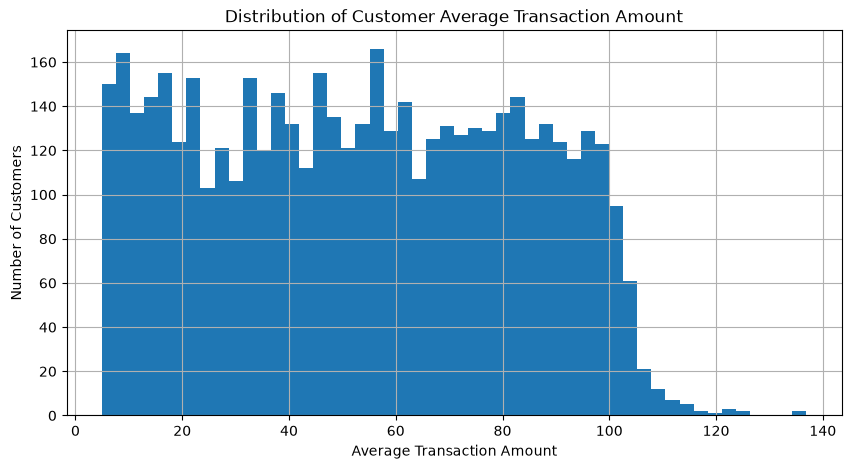

In [16]:
customer_activity["avg_amount"].hist(
    bins=50,
    figsize=(10, 5),
)

plt.title("Distribution of Customer Average Transaction Amount")
plt.xlabel("Average Transaction Amount")
plt.ylabel("Number of Customers")
plt.show()

In [17]:
customer_mean_amount = (
    df.groupby("CUSTOMER_ID")["TX_AMOUNT"]
    .mean()
    .rename("CUSTOMER_MEAN_AMOUNT")
)

customer_amount_analysis = df[
    ["CUSTOMER_ID", "TX_AMOUNT", "TX_FRAUD"]
].join(
    customer_mean_amount,
    on="CUSTOMER_ID",
)

customer_amount_analysis["AMOUNT_TO_CUSTOMER_MEAN"] = (
    customer_amount_analysis["TX_AMOUNT"]
    / customer_amount_analysis["CUSTOMER_MEAN_AMOUNT"]
)

In [18]:
customer_amount_analysis.groupby(
    "TX_FRAUD"
)["AMOUNT_TO_CUSTOMER_MEAN"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
TX_FRAUD,,,
0,0.989961,0.976478,0.456612
1,2.189466,1.329295,2.034498


**Observation:** Customer spending behavior varies substantially across the dataset, with average transaction amounts ranging from approximately 5 to 137.

Fraudulent transactions also deviate more strongly from a customer's typical spending behavior. The median transaction-to-customer-average ratio is approximately **0.98 for legitimate transactions** compared with **1.33 for fraudulent transactions**, while the mean ratio increases from approximately **0.99 to 2.19**.

This suggests that customer-relative transaction amount may provide a stronger behavioral signal than absolute transaction amount alone. The production feature pipeline will therefore construct historical customer statistics using only transactions that occurred before the transaction being scored, preventing future-information leakage.

## 8. Terminal Behavioral Analysis

Fraud risk may also depend on the terminal where a transaction occurs. Some terminals may exhibit different transaction volumes or historical fraud patterns.

This section explores terminal-level behavior and evaluates whether terminal history could provide useful predictive signals for the fraud detection model.

In [19]:
terminal_activity = (
    df.groupby("TERMINAL_ID")
    .agg(
        transaction_count=("TRANSACTION_ID", "count"),
        avg_amount=("TX_AMOUNT", "mean"),
        fraud_count=("TX_FRAUD", "sum"),
    )
)

terminal_activity["fraud_rate"] = (
    terminal_activity["fraud_count"]
    / terminal_activity["transaction_count"]
)

terminal_activity.describe()

,transaction_count,avg_amount,fraud_count,fraud_rate
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.415500,53.666434,1.468100,0.008292
std,39.170273,6.416164,5.144651,0.028277
min,47.000000,33.575385,0.000000,0.000000
25%,148.000000,49.164105,0.000000,0.000000
50%,171.000000,53.610478,0.000000,0.000000
75%,199.250000,58.018743,1.000000,0.006135
max,376.000000,78.279231,85.000000,0.356436


In [20]:
terminal_activity.sort_values(
    ["fraud_rate", "transaction_count"],
    ascending=[False, False],
).head(15)

,transaction_count,avg_amount,fraud_count,fraud_rate
TERMINAL_ID,,,,
1244,202,43.420396,72,0.356436
7054,155,55.105097,50,0.322581
293,297,60.960135,85,0.286195
3644,217,61.132396,59,0.271889
596,174,51.448506,46,0.264368
4996,127,47.890157,31,0.244094
2528,136,52.379338,31,0.227941
4876,208,50.822452,44,0.211538
9585,152,53.334474,32,0.210526


In [21]:
active_terminals = terminal_activity[
    terminal_activity["transaction_count"] >= 100
]

active_terminals.sort_values(
    "fraud_rate",
    ascending=False,
).head(15)

,transaction_count,avg_amount,fraud_count,fraud_rate
TERMINAL_ID,,,,
1244,202,43.420396,72,0.356436
7054,155,55.105097,50,0.322581
293,297,60.960135,85,0.286195
3644,217,61.132396,59,0.271889
596,174,51.448506,46,0.264368
4996,127,47.890157,31,0.244094
2528,136,52.379338,31,0.227941
4876,208,50.822452,44,0.211538
9585,152,53.334474,32,0.210526


In [22]:
terminal_activity["fraud_rate"].describe()

count    10000.000000
mean         0.008292
std          0.028277
min          0.000000
25%          0.000000
50%          0.000000
75%          0.006135
max          0.356436
Name: fraud_rate, dtype: float64

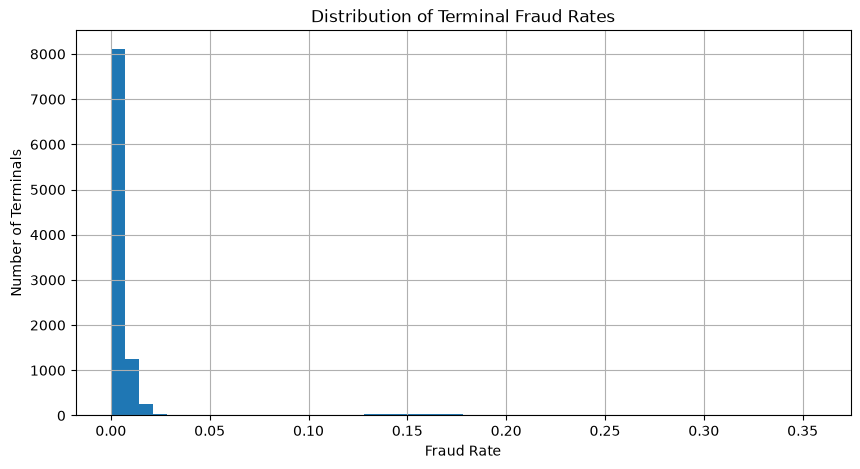

In [23]:
terminal_activity["fraud_rate"].hist(
    bins=50,
    figsize=(10, 5),
)

plt.title("Distribution of Terminal Fraud Rates")
plt.xlabel("Fraud Rate")
plt.ylabel("Number of Terminals")
plt.show()

In [24]:
terminals_with_fraud = (
    terminal_activity["fraud_count"] > 0
).sum()

terminals_without_fraud = (
    terminal_activity["fraud_count"] == 0
).sum()

print(f"Terminals with fraud: {terminals_with_fraud:,}")
print(f"Terminals without fraud: {terminals_without_fraud:,}")
print(
    "Percentage of terminals with fraud:",
    f"{terminals_with_fraud / len(terminal_activity) * 100:.2f}%"
)

Terminals with fraud: 4,266
Terminals without fraud: 5,734
Percentage of terminals with fraud: 42.66%


In [25]:
fraud_by_terminal = (
    terminal_activity["fraud_count"]
    .sort_values(ascending=False)
)

total_frauds = fraud_by_terminal.sum()

for top_n in [10, 50, 100, 500]:
    share = (
        fraud_by_terminal.head(top_n).sum()
        / total_frauds
        * 100
    )

    print(
        f"Top {top_n} terminals account for "
        f"{share:.2f}% of fraud transactions."
    )

Top 10 terminals account for 3.72% of fraud transactions.
Top 50 terminals account for 14.26% of fraud transactions.
Top 100 terminals account for 25.19% of fraud transactions.
Top 500 terminals account for 66.77% of fraud transactions.


**Observation:** Fraudulent transactions are strongly concentrated among a relatively small subset of terminals. Although only 42.66% of terminals contain at least one fraudulent transaction, the top 100 terminals account for approximately **25.19%** of all fraud transactions, while the top 500 terminals account for approximately **66.77%**.

Terminal-level fraud rates are highly skewed. Most terminals exhibit little or no fraud activity, while a small group shows substantially elevated fraud rates, in some cases exceeding 20–30%.

These results indicate that historical terminal behavior may provide a strong predictive signal. The production feature pipeline will therefore construct rolling terminal transaction counts and historical fraud statistics using only information available before each transaction.

## 9. Key Findings and Feature Engineering Strategy

The exploratory analysis identified several important characteristics of the dataset:

- Fraud is highly imbalanced, representing approximately **0.84%** of all transactions.
- Fraudulent transactions tend to have higher transaction amounts than legitimate transactions.
- Raw hour-of-day and day-of-week variables show only limited differences in fraud rates and are expected to provide contextual rather than dominant predictive signals.
- Customer-relative transaction behavior provides a stronger signal: fraudulent transactions deviate substantially more from customers' typical spending patterns.
- Fraud is strongly concentrated among a subset of terminals, indicating that historical terminal behavior may provide substantial predictive value.
- `TX_FRAUD_SCENARIO` directly reflects the fraud-generation process and will be excluded from modeling to prevent target leakage.
- Customer and terminal identifiers will be used only to construct behavioral features and will not be supplied directly to the models.

Based on these findings, the modeling pipeline will combine transaction-level information with leakage-free historical customer and terminal features. All historical features will be computed using only transactions occurring before the transaction being scored.